# From Order to Chaos in the Rössler System

In [14]:
# ==============================================================
# Imports and setup
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider, IntSlider


plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

# ==============================================================
# Define the Rössler system
# ==============================================================
def rossler(t, state, a, b, c):
    x, y, z = state
    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)
    return [dxdt, dydt, dzdt]

# ==============================================================
# Integrate and plot function
# ==============================================================
def simulate_rossler(a=0.2, b=0.2, c=4.0, t_max=200):
    t_span = (0, t_max)
    t_eval = np.linspace(200, t_max, 40000)
    y0 = [1.0, 0.0, 0.0]

    sol = solve_ivp(rossler, t_span, y0, t_eval=t_eval, args=(a, b, c), rtol=1e-6)
    x, y, z = sol.y
    t = sol.t

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(t, x, lw=0.7)
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("x(t)")
    axes[0].set_title("Time series")

    axes[1].plot(x, z, lw=0.7)
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("z")
    axes[1].set_title("Phase portrait (x, z)")

    plt.tight_layout()
    plt.show()

# ==============================================================
# Interactive exploration
# ==============================================================

interact(simulate_rossler,
c=FloatSlider(value=4.0, min=3.0, max=10.0, step=0.1, description="c"),
a=FloatSlider(value=0.2, min=0.0, max=0.4, step=0.01, description="a"),
b=FloatSlider(value=0.2, min=0.0, max=0.4, step=0.01, description="b"),
t_max=FloatSlider(value=400, min=300, max=500, step=10, description="t_max"));

interactive(children=(FloatSlider(value=0.2, description='a', max=0.4, step=0.01), FloatSlider(value=0.2, desc…

## Optional: Poincaré Section (x crossings at y=0)

In [11]:
def rossler_poincare(a=0.2, b=0.2, c=4.0, t_max=500):
    t_span = (0, t_max)
    t_eval = np.linspace(300, t_max, 100000)
    y0 = [1.0, 0.0, 0.0]

    sol = solve_ivp(rossler, t_span, y0, t_eval=t_eval, args=(a, b, c), rtol=1e-6)
    x, y, z = sol.y

    # Detect upward y=0 crossings
    crossings = (y[:-1] < 0) & (y[1:] >= 0)
    x_cross = x[:-1][crossings]
    z_cross = z[:-1][crossings]

    plt.figure(figsize=(5,4))
    plt.scatter(x_cross, z_cross, s=1)
    plt.xlabel("x at y=0")
    plt.ylabel("z at y=0")
    plt.title(f"Poincaré section, c={c:.2f}")
    plt.show()

In [12]:
interact(rossler_poincare,
c=FloatSlider(value=4.0, min=3.0, max=10.0, step=0.1, description="c"),
a=FloatSlider(value=0.2, min=0.0, max=0.4, step=0.01, description="a"),
b=FloatSlider(value=0.2, min=0.0, max=0.4, step=0.01, description="b"),
t_max=FloatSlider(value=800, min=400, max=1000, step=50, description="t_max"));

interactive(children=(FloatSlider(value=0.2, description='a', max=0.4, step=0.01), FloatSlider(value=0.2, desc…

## Optional: Bifurcation Diagram vs c

In [8]:
def rossler_bifurcation(a=0.2, b=0.2, c_min=3.0, c_max=10.0, c_steps=150, t_transient=200, t_sample=500):
    c_values = np.linspace(c_min, c_max, c_steps)
    x_crossings_all = []

    for c in c_values:
        t_span = (0, t_sample)
        t_eval = np.linspace(*t_span, 50000)
        y0 = [1.0, 0.0, 0.0]

        sol = solve_ivp(rossler, t_span, y0, t_eval=t_eval, args=(a, b, c), rtol=1e-6)
        x, y, z = sol.y

        # Ignore transient
        x = x[t_eval > t_transient]
        y = y[t_eval > t_transient]

        # Upward y=0 crossings
        crossings = (y[:-1] < 0) & (y[1:] >= 0)
        x_cross = x[:-1][crossings]
        x_crossings_all.append(x_cross)

    plt.figure(figsize=(8,6))
    for i, x_cross in enumerate(x_crossings_all):
        c = c_values[i]
        plt.scatter([c]*len(x_cross), x_cross, color='black', s=0.5)
    plt.xlabel("c")
    plt.ylabel("x at y=0 (Poincaré)")
    plt.title("Bifurcation diagram of Rössler system vs c")
    plt.show()

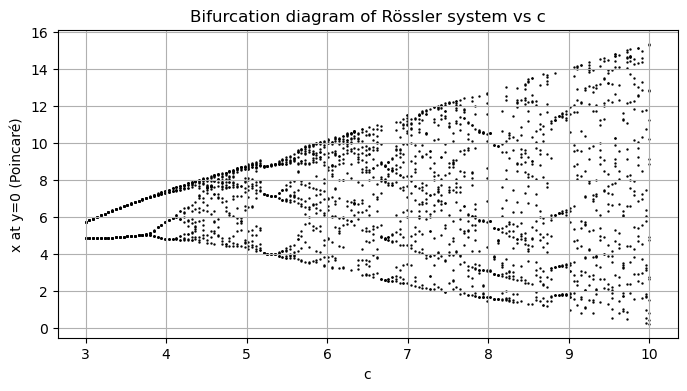

In [7]:
rossler_bifurcation();